In [ ]:
# ============================================================
# EXPERIMENTS: CURVATURE-BASED FINANCIAL NETWORK ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

returns = pd.read_csv("returns_2005_2015.csv", index_col=0, parse_dates=True)

print(returns.shape)
returns.head()

(118, 401)


,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2006-03-01,0.042154,-0.088007,-0.039474,0.020648,-0.082623,-0.098038,0.007098,0.062307,-0.011104,0.022845,...,0.046093,0.072558,-0.005240,0.066050,0.145406,-0.022338,0.030086,0.024028,-0.023104,0.013054
2006-04-01,0.022905,0.115371,0.006337,0.050817,-0.033821,0.114758,-0.009710,0.076906,-0.031606,0.087444,...,-0.012579,0.025591,0.032603,-0.027434,-0.009676,0.049072,0.035827,0.056111,-0.072062,-0.119322
2006-05-01,-0.096378,-0.163547,0.006082,-0.056723,-0.032160,-0.314222,-0.117091,0.134460,0.031047,-0.144328,...,-0.144493,-0.042403,-0.011446,-0.096929,-0.066687,-0.003723,-0.035006,-0.022668,-0.038076,-0.116933
2006-06-01,-0.100310,-0.042727,0.021087,0.035260,0.006021,0.058671,-0.043519,-0.004732,-0.002643,-0.054495,...,-0.059847,0.064318,-0.079323,-0.019867,0.029068,0.021608,0.012215,-0.002582,-0.065343,-0.033111
2006-07-01,-0.104094,0.171142,0.091111,0.023272,0.032653,-0.062871,0.005894,0.063812,-0.031633,-0.010209,...,-0.068364,0.067154,0.020622,-0.059401,-0.135521,0.055563,0.099082,-0.110747,0.108810,-0.085841


In [ ]:
# ------------------------------------------------------------
# Define market regimes
# ------------------------------------------------------------

regimes = {
    "Pre-crisis": returns.loc["2005":"2007"],
    "Crisis": returns.loc["2008":"2009"],
    "Post-crisis": returns.loc["2010":"2015"]
}

In [ ]:
# ------------------------------------------------------------
# Build correlation networks
# ------------------------------------------------------------

def build_corr_network(data, threshold=0.4):
    corr = data.corr()
    G = nx.Graph()

    stocks = list(corr.columns)
    G.add_nodes_from(stocks)

    for a in range(len(stocks)):
        for b in range(a + 1, len(stocks)):
            i, j = stocks[a], stocks[b]
            rho = corr.loc[i, j]

            if pd.notna(rho) and rho > threshold:
                G.add_edge(i, j, weight=float(rho))

    return G, corr


threshold = 0.4

graphs = {}
corrs = {}

for name, data in regimes.items():
    G, corr = build_corr_network(data, threshold=threshold)
    graphs[name] = G
    corrs[name] = corr

    print(f"{name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Pre-crisis: 401 nodes, 10637 edges
Crisis: 401 nodes, 43289 edges
Post-crisis: 401 nodes, 25580 edges


In [ ]:
# ------------------------------------------------------------
# Forman-Ricci curvature for weighted undirected graphs
# ------------------------------------------------------------

class FormanRicci:
    def __init__(self, G):
        self.G = G.copy()

    def compute_ricci_curvature(self):
        """
        Compute the Forman-Ricci curvature for all edges and nodes
        in an undirected graph G.
        """
        if self.G.is_directed():
            raise ValueError("The graph must be undirected.")

        curvature = {}

        for u, v in self.G.edges():
            w_e = self.G[u][v].get("weight", 1)
            w_u = self.G.nodes[u].get("weight", 1)
            w_v = self.G.nodes[v].get("weight", 1)

            sum_u = 0
            sum_v = 0

            for _, u_neigh in self.G.edges(u):
                if u_neigh != v:
                    w_u_neigh = self.G[u][u_neigh].get("weight", 1)
                    sum_u += w_u / np.sqrt(w_e * w_u_neigh)

            for _, v_neigh in self.G.edges(v):
                if v_neigh != u:
                    w_v_neigh = self.G[v][v_neigh].get("weight", 1)
                    sum_v += w_v / np.sqrt(w_e * w_v_neigh)

            F_e = w_e * (w_u / w_e + w_v / w_e - sum_u - sum_v)

            curvature[(u, v)] = F_e
            self.G[u][v]["formanCurvature"] = F_e

        for n in self.G.nodes():
            fcsum = 0
            if self.G.degree(n) != 0:
                for nbr in self.G.neighbors(n):
                    if "formanCurvature" in self.G[n][nbr]:
                        fcsum += self.G[n][nbr]["formanCurvature"]
                self.G.nodes[n]["formanCurvature"] = fcsum / self.G.degree(n)
            else:
                self.G.nodes[n]["formanCurvature"] = 0

        print("Forman curvature computation done.")
        return self.G

In [ ]:
# ============================================================
# Apply our Forman-Ricci curvature class
# ============================================================

curv_graphs = {}

for name, G in graphs.items():
    frc = FormanRicci(G)
    curv_graphs[name] = frc.compute_ricci_curvature()

    print(
        f"{name}: {curv_graphs[name].number_of_nodes()} nodes, "
        f"{curv_graphs[name].number_of_edges()} edges"
    )

Forman curvature computation done.
Pre-crisis: 401 nodes, 10637 edges
Forman curvature computation done.
Crisis: 401 nodes, 43289 edges
Forman curvature computation done.
Post-crisis: 401 nodes, 25580 edges


In [ ]:
# ============================================================
# Summarize network and curvature statistics
# ============================================================

def summarize_graph(G, label):
    degrees = [d for _, d in G.degree()]
    curvatures = [
        data["formanCurvature"]
        for _, _, data in G.edges(data=True)
        if "formanCurvature" in data
    ]

    summary = {
        "Regime": label,
        "Nodes": G.number_of_nodes(),
        "Edges": G.number_of_edges(),
        "Density": nx.density(G),
        "Average Degree": np.mean(degrees),
        "Mean FRC": np.mean(curvatures),
        "Std FRC": np.std(curvatures),
        "Min FRC": np.min(curvatures),
        "Max FRC": np.max(curvatures),
        "Negative FRC Ratio": np.mean(np.array(curvatures) < 0),
    }

    return summary


summary_df = pd.DataFrame([
    summarize_graph(G, name)
    for name, G in curv_graphs.items()
])

summary_df

,Regime,Nodes,Edges,Density,Average Degree,Mean FRC,Std FRC,Min FRC,Max FRC,Negative FRC Ratio
0,Pre-crisis,401,10637,0.132631,53.052369,-132.416527,46.059117,-318.514848,-6.087371,1.000000
1,Crisis,401,43289,0.539763,215.905237,-494.488971,115.081952,-820.096551,-39.579949,1.000000
2,Post-crisis,401,25580,0.318953,127.581047,-364.563690,108.401936,-676.370499,2.000000,0.999961


In [ ]:
# ============================================================
# Identify systemic nodes using centrality and curvature
# Fixed for disconnected graphs
# ============================================================

def safe_eigenvector_centrality(G, weight="weight"):
    """
    Compute eigenvector centrality safely for disconnected graphs.
    """
    try:
        return nx.eigenvector_centrality(
            G,
            max_iter=1000,
            tol=1e-06,
            weight=weight
        )
    except nx.PowerIterationFailedConvergence:
        print("Eigenvector centrality did not converge. Using zero values.")
        return {node: 0.0 for node in G.nodes()}


def systemic_node_table(G, top_n=20):
    degree_cent = nx.degree_centrality(G)
    eigen_cent = safe_eigenvector_centrality(G, weight="weight")

    rows = []

    for node in G.nodes():
        rows.append({
            "Stock": node,
            "Degree": G.degree(node),
            "Degree Centrality": degree_cent.get(node, 0),
            "Eigenvector Centrality": eigen_cent.get(node, 0),
            "Node FRC": G.nodes[node].get("formanCurvature", 0),
        })

    df = pd.DataFrame(rows)

    df["Curvature Fragility Score"] = -df["Node FRC"]

    df["Systemic Risk Score"] = (
        df["Degree Centrality"].rank(pct=True)
        + df["Eigenvector Centrality"].rank(pct=True)
        + df["Curvature Fragility Score"].rank(pct=True)
    ) / 3

    return df.sort_values("Systemic Risk Score", ascending=False).head(top_n)


for name, G in curv_graphs.items():
    print(f"\nTop systemic nodes: {name}")
    display(systemic_node_table(G, top_n=20))


Top systemic nodes: Pre-crisis


,Stock,Degree,Degree Centrality,Eigenvector Centrality,Node FRC,Curvature Fragility Score,Systemic Risk Score
174,HAS,139,0.3475,0.125170,-210.664972,210.664972,0.998337
171,GS,140,0.3500,0.123396,-211.356181,211.356181,0.997506
25,AMP,138,0.3450,0.120579,-210.597150,210.597150,0.992519
339,SWK,128,0.3200,0.120777,-203.204352,203.204352,0.990856
352,TMO,131,0.3275,0.116376,-202.933835,202.933835,0.989194
134,EQR,117,0.2925,0.123642,-195.664110,195.664110,0.988362
35,AVB,116,0.2900,0.124665,-194.964633,194.964633,0.987531
253,MS,118,0.2950,0.112608,-191.800483,191.800483,0.982544
312,RJF,115,0.2875,0.110355,-190.138868,190.138868,0.975062
398,YUM,119,0.2975,0.101779,-190.821422,190.821422,0.974231



Top systemic nodes: Crisis


,Stock,Degree,Degree Centrality,Eigenvector Centrality,Node FRC,Curvature Fragility Score,Systemic Risk Score
112,DOV,344,0.8600,0.077437,-597.280632,597.280632,0.997091
5,ADBE,337,0.8425,0.077729,-594.640979,594.640979,0.996675
313,RL,338,0.8450,0.077523,-594.192357,594.192357,0.995012
201,IVZ,344,0.8600,0.074870,-592.810084,592.810084,0.985453
121,EBAY,328,0.8200,0.077653,-589.740707,589.740707,0.985453
179,HON,330,0.8250,0.077003,-589.320750,589.320750,0.985037
9,ADSK,336,0.8400,0.075782,-590.546820,590.546820,0.984206
300,PPG,329,0.8225,0.076062,-587.297407,587.297407,0.978387
108,DIS,328,0.8200,0.076298,-587.180121,587.180121,0.977972
356,TROW,326,0.8150,0.076193,-586.090146,586.090146,0.973400



Top systemic nodes: Post-crisis


,Stock,Degree,Degree Centrality,Eigenvector Centrality,Node FRC,Curvature Fragility Score,Systemic Risk Score
179,HON,282,0.7050,0.098327,-467.627753,467.627753,0.998337
107,DHR,289,0.7225,0.094646,-467.707626,467.707626,0.997506
356,TROW,281,0.7025,0.095787,-464.943052,464.943052,0.995844
201,IVZ,274,0.6850,0.095110,-460.427224,460.427224,0.992519
25,AMP,272,0.6800,0.094524,-458.803600,458.803600,0.988778
278,OMC,279,0.6975,0.089602,-457.597254,457.597254,0.985869
246,MMM,272,0.6800,0.090006,-454.435034,454.435034,0.982959
190,IEX,267,0.6675,0.093837,-455.668956,455.668956,0.982544
164,GL,268,0.6700,0.091084,-453.327491,453.327491,0.981297
328,SNA,266,0.6650,0.090286,-451.219940,451.219940,0.977140


In [ ]:
# ============================================================
# Identify most fragile edges
# ============================================================

def fragile_edges_table(G, top_n=20):
    rows = []

    for u, v, data in G.edges(data=True):
        rows.append({
            "Stock i": u,
            "Stock j": v,
            "Correlation Weight": data.get("weight", 0),
            "Forman-Ricci Curvature": data.get("formanCurvature", 0),
        })

    df = pd.DataFrame(rows)
    return df.sort_values("Forman-Ricci Curvature", ascending=True).head(top_n)


for name, G in curv_graphs.items():
    print(f"\nMost fragile edges: {name}")
    display(fragile_edges_table(G, top_n=20))


Most fragile edges: Pre-crisis


,Stock i,Stock j,Correlation Weight,Forman-Ricci Curvature
1298,AMP,SWK,0.734030,-318.514848
7093,GS,HAS,0.632743,-309.975981
1795,AVB,EQR,0.895769,-303.930037
7111,GS,MCD,0.741008,-300.460179
1239,AMP,HAS,0.588796,-296.746521
1265,AMP,MET,0.705660,-294.913715
1237,AMP,GS,0.573377,-294.900825
1303,AMP,TMO,0.602455,-293.531453
6682,GD,GS,0.744137,-292.994237
1797,AVB,ESS,0.919334,-290.301271



Most fragile edges: Crisis


,Stock i,Stock j,Correlation Weight,Forman-Ricci Curvature
20594,DOV,IEX,0.900993,-820.096551
14809,CMI,IEX,0.948761,-818.672027
9420,BEN,IVZ,0.864420,-818.254511
20604,DOV,IVZ,0.847305,-815.202026
17344,CSCO,RL,0.904139,-811.707425
17280,CSCO,LRCX,0.926613,-807.172637
35587,LRCX,RL,0.900492,-806.975595
14745,CMI,DOV,0.884559,-806.043373
1892,ADSK,FICO,0.889335,-799.947428
1044,ADBE,CSCO,0.878426,-796.942193



Most fragile edges: Post-crisis


,Stock i,Stock j,Correlation Weight,Forman-Ricci Curvature
11794,DHR,OMC,0.797623,-676.370499
11723,DHR,HON,0.811283,-674.962964
17186,HON,TROW,0.839737,-674.161520
11774,DHR,MMM,0.783950,-659.907742
17127,HON,OMC,0.790535,-659.645296
3803,AMP,TROW,0.817220,-656.451855
11815,DHR,PSKY,0.774141,-656.135494
18380,IPG,OMC,0.816851,-656.083585
3689,AMP,IVZ,0.839208,-655.961989
18689,IVZ,OMC,0.799439,-655.752867


In [ ]:
# ============================================================
# Curvature-Based Shock Propagation
# Improved curvature-aware transition matrix
# ============================================================

def build_transition_matrix(G, curvature_adjusted=False, alpha=0.05):

    nodes = list(G.nodes())
    idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)

    A = np.zeros((n, n))

    # --------------------------------------------------------
    # Collect all curvature values for normalization
    # --------------------------------------------------------

    frc_values = [
        data.get("formanCurvature", 0)
        for _, _, data in G.edges(data=True)
    ]

    frc_mean = np.mean(frc_values)
    frc_std = np.std(frc_values)

    # --------------------------------------------------------
    # Build adjacency / transition matrix
    # --------------------------------------------------------

    for u, v, data in G.edges(data=True):

        w = data.get("weight", 0.0)
        frc = data.get("formanCurvature", 0.0)

        # ----------------------------------------------------
        # Normalize curvature
        # ----------------------------------------------------

        frc_norm = (frc - frc_mean) / (frc_std + 1e-8)

        # ----------------------------------------------------
        # Curvature-adjusted propagation
        # Negative curvature -> amplify contagion
        # Positive curvature -> damp contagion
        # ----------------------------------------------------

        if curvature_adjusted:

            if frc_norm < 0:
                adjusted_w = w * (1 + alpha * abs(frc_norm))
            else:
                adjusted_w = w / (1 + alpha * frc_norm)

        else:
            adjusted_w = w

        A[idx[u], idx[v]] = adjusted_w
        A[idx[v], idx[u]] = adjusted_w

    # --------------------------------------------------------
    # Row-normalize transition matrix
    # --------------------------------------------------------

    row_sums = A.sum(axis=1, keepdims=True)

    W = np.divide(
        A,
        row_sums,
        out=np.zeros_like(A),
        where=row_sums != 0
    )

    return W, nodes, idx

In [ ]:
# ------------------------------------------------------------
# Shock propagation function
# ------------------------------------------------------------
def propagate_shock(
    G,
    shocked_node,
    shock_size=0.5,
    gamma=0.95,
    max_steps=25,
    curvature_adjusted=False,
    alpha=0.05
):
    W, nodes, idx = build_transition_matrix(
        G,
        curvature_adjusted=curvature_adjusted,
        alpha=alpha
    )

    d = np.zeros(len(nodes))
    d[idx[shocked_node]] = shock_size

    cumulative_distress = d.copy()
    total_distress = [cumulative_distress.sum()]
    distress_history = [d.copy()]

    for _ in range(max_steps):
        d_next = gamma * (W @ d)

        cumulative_distress += d_next
        d = d_next

        distress_history.append(d.copy())
        total_distress.append(cumulative_distress.sum())

    impacted = pd.Series(
        cumulative_distress,
        index=nodes
    ).sort_values(ascending=False)

    return {
        "impacted": impacted,
        "total_distress": total_distress,
        "distress_history": distress_history,
        "nodes": nodes
    }

In [ ]:
# ------------------------------------------------------------
# Select shock source
# ------------------------------------------------------------
# Example: use the most central pre-crisis node

pre_graph = curv_graphs["Pre-crisis"]
crisis_graph = curv_graphs["Crisis"]

degree_cent_pre = nx.degree_centrality(pre_graph)
shock_node = max(degree_cent_pre, key=degree_cent_pre.get)

print("Selected shock node:", shock_node)
# ------------------------------------------------------------
# 6.3 Run baseline and curvature-adjusted propagation
# ------------------------------------------------------------

baseline_result = propagate_shock(
    crisis_graph,
    shocked_node=shock_node,
    shock_size=0.5,
    gamma=0.95,
    max_steps=25,
    curvature_adjusted=False
)

curvature_result = propagate_shock(
    crisis_graph,
    shocked_node=shock_node,
    shock_size=0.5,
    gamma=0.95,
    max_steps=25,
    curvature_adjusted=True,
    alpha=0.5   # increased from 0.05
)

print("Final baseline distress:", baseline_result["total_distress"][-1])
print("Final curvature-adjusted distress:", curvature_result["total_distress"][-1])
print(
    "Difference:",
    curvature_result["total_distress"][-1]
    - baseline_result["total_distress"][-1]
)

Selected shock node: GS
Final baseline distress: 8.495067454710494
Final curvature-adjusted distress: 8.384475052569432
Difference: -0.11059240214106225


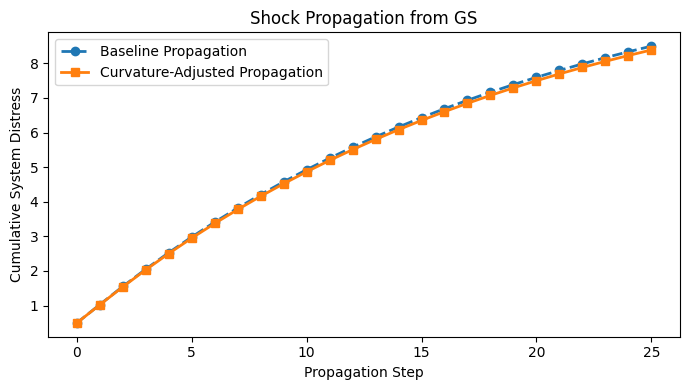

In [ ]:
# ------------------------------------------------------------
# Compare systemic distress build-up
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))

plt.plot(
    baseline_result["total_distress"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Baseline Propagation"
)

plt.plot(
    curvature_result["total_distress"],
    marker="s",
    linestyle="-",
    linewidth=2,
    label="Curvature-Adjusted Propagation"
)

plt.xlabel("Propagation Step")
plt.ylabel("Cumulative System Distress")
plt.title(f"Shock Propagation from {shock_node}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Compare top impacted firms
# ------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Baseline Distress": baseline_result["impacted"],
    "Curvature-Adjusted Distress": curvature_result["impacted"]
})

comparison_df["Difference"] = (
    comparison_df["Curvature-Adjusted Distress"]
    - comparison_df["Baseline Distress"]
)

comparison_df.sort_values(
    "Curvature-Adjusted Distress",
    ascending=False
).head(20)

,Baseline Distress,Curvature-Adjusted Distress,Difference
GS,0.519444,0.519095,-0.000349
CF,0.026444,0.028055,0.001611
VTRS,0.025023,0.025739,0.000717
AKAM,0.025729,0.025554,-0.000175
SWKS,0.024856,0.025495,0.000639
EW,0.025083,0.025222,0.000139
MOS,0.024498,0.025097,0.000599
TJX,0.024569,0.025093,0.000523
BKNG,0.024981,0.025088,0.000107
DXCM,0.024279,0.024574,0.000295


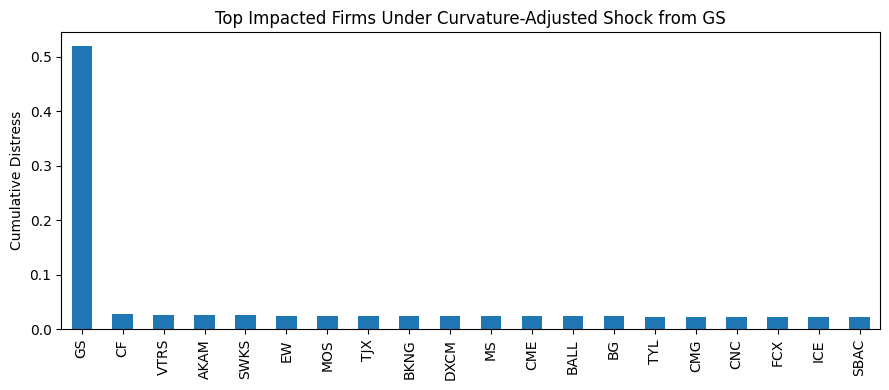

In [ ]:
# ------------------------------------------------------------
# Plot top impacted firms under curvature-adjusted model
# ------------------------------------------------------------

top_impacted = curvature_result["impacted"].head(20)

plt.figure(figsize=(9, 4))
top_impacted.plot(kind="bar")
plt.ylabel("Cumulative Distress")
plt.title(f"Top Impacted Firms Under Curvature-Adjusted Shock from {shock_node}")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Regime-level shock propagation comparison
# ------------------------------------------------------------

regime_shock_results = []

for name, G in curv_graphs.items():
    degree_cent = nx.degree_centrality(G)
    source = max(degree_cent, key=degree_cent.get)

    result = propagate_shock(
        G,
        shocked_node=source,
        shock_size=0.5,
        gamma=0.95,
        max_steps=25,
        curvature_adjusted=True,
        alpha=0.5
    )

    regime_shock_results.append({
        "Regime": name,
        "Shock Node": source,
        "Final System Distress": result["total_distress"][-1],
        "Max Node Distress": result["impacted"].max(),
        "Mean Node Distress": result["impacted"].mean()
    })

regime_shock_df = pd.DataFrame(regime_shock_results)
regime_shock_df

,Regime,Shock Node,Final System Distress,Max Node Distress,Mean Node Distress
0,Pre-crisis,GS,31.474205,0.581997,0.078489
1,Crisis,DOV,16.813009,0.538172,0.041928
2,Post-crisis,DHR,24.276335,0.557207,0.060539


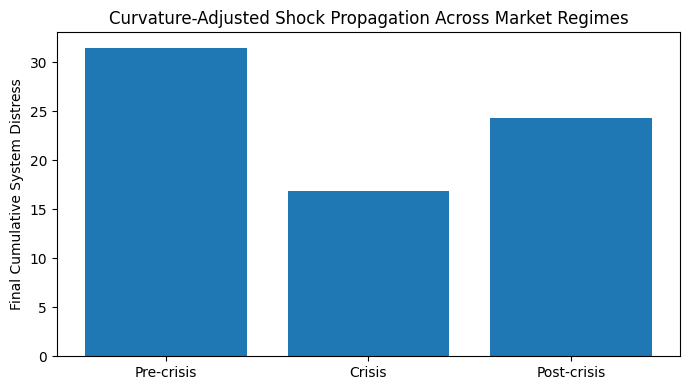

In [ ]:
# ------------------------------------------------------------
# Plot final systemic distress by regime
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.bar(
    regime_shock_df["Regime"],
    regime_shock_df["Final System Distress"]
)

plt.ylabel("Final Cumulative System Distress")
plt.title("Curvature-Adjusted Shock Propagation Across Market Regimes")
plt.tight_layout()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Baseline": baseline_result["impacted"],
    "Curvature_Adjusted": curvature_result["impacted"]
})

comparison_df["Difference"] = (
    comparison_df["Curvature_Adjusted"]
    - comparison_df["Baseline"]
)

comparison_df.sort_values(
    "Difference",
    ascending=False
).head(20)

,Baseline,Curvature_Adjusted,Difference
CF,0.026444,0.028055,0.001611
FCX,0.022287,0.023125,0.000838
VTRS,0.025023,0.025739,0.000717
MS,0.023800,0.024501,0.000701
SWKS,0.024856,0.025495,0.000639
MOS,0.024498,0.025097,0.000599
BG,0.023143,0.023687,0.000544
TJX,0.024569,0.025093,0.000523
EA,0.021780,0.022110,0.000330
APH,0.021241,0.021554,0.000313


In [ ]:
comparison_df.sort_values(
    "Difference",
    ascending=True
).head(20)

,Baseline,Curvature_Adjusted,Difference
KIM,0.019715,0.018972,-0.000743
BF-B,0.020272,0.019534,-0.000738
EXR,0.019698,0.018979,-0.000719
DOC,0.019983,0.019294,-0.000689
VLO,0.020642,0.019955,-0.000687
NVR,0.019777,0.019092,-0.000685
DD,0.019769,0.019088,-0.000681
JPM,0.020144,0.019475,-0.000669
BSX,0.020533,0.019868,-0.000665
STZ,0.020545,0.019885,-0.000660


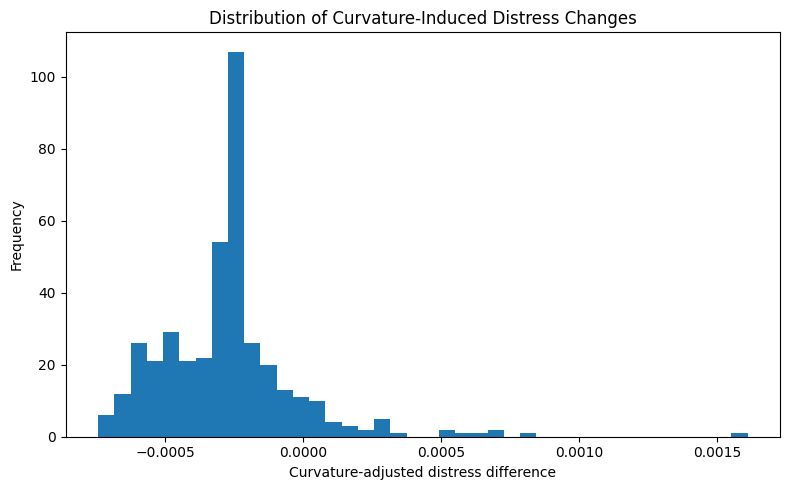

In [ ]:
plt.figure(figsize=(8,5))

comparison_df["Difference"].sort_values().plot(kind="hist", bins=40)

plt.xlabel("Curvature-adjusted distress difference")
plt.title("Distribution of Curvature-Induced Distress Changes")
plt.tight_layout()
plt.show()

In [ ]:
top_amplified = comparison_df.sort_values(
    "Difference",
    ascending=False
).head(20)

top_amplified

,Baseline,Curvature_Adjusted,Difference
CF,0.026444,0.028055,0.001611
FCX,0.022287,0.023125,0.000838
VTRS,0.025023,0.025739,0.000717
MS,0.023800,0.024501,0.000701
SWKS,0.024856,0.025495,0.000639
MOS,0.024498,0.025097,0.000599
BG,0.023143,0.023687,0.000544
TJX,0.024569,0.025093,0.000523
EA,0.021780,0.022110,0.000330
APH,0.021241,0.021554,0.000313


In [ ]:
#Threshold sensitivity analysis
threshold_values = [0.3, 0.4, 0.5, 0.6]
threshold_results = []

for th in threshold_values:
    for regime_name, data in regimes.items():
        G, _ = build_corr_network(data, threshold=th)
        G = FormanRicci(G).compute_ricci_curvature()

        curvatures = [
            d["formanCurvature"]
            for _, _, d in G.edges(data=True)
        ]

        threshold_results.append({
            "Threshold": th,
            "Regime": regime_name,
            "Nodes": G.number_of_nodes(),
            "Edges": G.number_of_edges(),
            "Density": nx.density(G),
            "Mean FRC": np.mean(curvatures),
            "Negative FRC Ratio": np.mean(np.array(curvatures) < 0)
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.


,Threshold,Regime,Nodes,Edges,Density,Mean FRC,Negative FRC Ratio
0,0.3,Pre-crisis,401,20643,0.257394,-240.662392,1.000000
1,0.3,Crisis,401,56628,0.706085,-606.643924,1.000000
2,0.3,Post-crisis,401,42192,0.526085,-501.743081,1.000000
3,0.4,Pre-crisis,401,10637,0.132631,-132.416527,1.000000
4,0.4,Crisis,401,43289,0.539763,-494.488971,1.000000
5,0.4,Post-crisis,401,25580,0.318953,-364.563690,0.999961
6,0.5,Pre-crisis,401,4409,0.054975,-59.813149,0.999773
7,0.5,Crisis,401,28807,0.359190,-367.649575,1.000000
8,0.5,Post-crisis,401,12603,0.157145,-234.510297,0.999841
9,0.6,Pre-crisis,401,1395,0.017394,-22.414319,0.986380


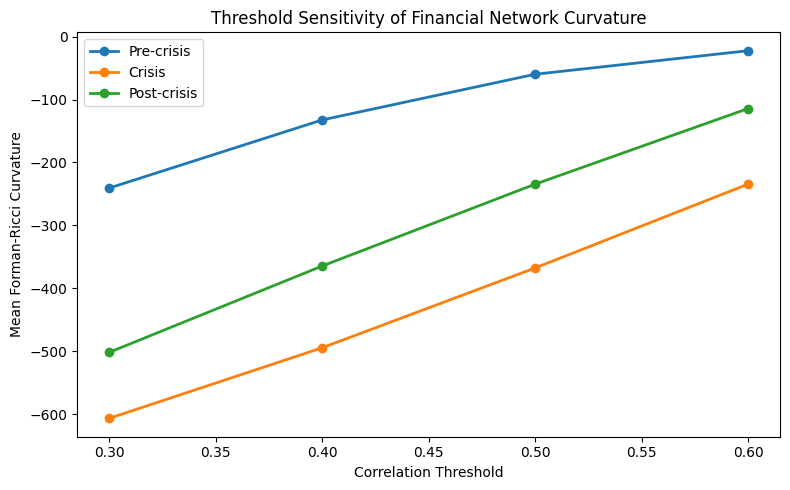

In [ ]:
plt.figure(figsize=(8,5))

for regime in threshold_df["Regime"].unique():

    subset = threshold_df[
        threshold_df["Regime"] == regime
    ]

    plt.plot(
        subset["Threshold"],
        subset["Mean FRC"],
        marker="o",
        linewidth=2,
        label=regime
    )

plt.xlabel("Correlation Threshold")
plt.ylabel("Mean Forman-Ricci Curvature")
plt.title("Threshold Sensitivity of Financial Network Curvature")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
 #Centrality vs curvature ranking overlap
def ranking_overlap(G, top_n=25):
    degree_cent = nx.degree_centrality(G)

    node_frc = {
        node: G.nodes[node].get("formanCurvature", 0)
        for node in G.nodes()
    }

    top_degree = set(
        sorted(degree_cent, key=degree_cent.get, reverse=True)[:top_n]
    )

    top_fragile = set(
        sorted(node_frc, key=node_frc.get)[:top_n]
    )

    overlap = len(top_degree.intersection(top_fragile))

    return {
        "Top N": top_n,
        "Overlap Count": overlap,
        "Overlap Ratio": overlap / top_n
    }


overlap_results = []

for name, G in curv_graphs.items():
    result = ranking_overlap(G, top_n=25)
    result["Regime"] = name
    overlap_results.append(result)

overlap_df = pd.DataFrame(overlap_results)
overlap_df

,Top N,Overlap Count,Overlap Ratio,Regime
0,25,23,0.92,Pre-crisis
1,25,21,0.84,Crisis
2,25,20,0.80,Post-crisis


In [ ]:
def compare_centralities(G, top_n=25):

    degree_cent = nx.degree_centrality(G)

    eigen_cent = safe_eigenvector_centrality(
        G,
        weight="weight"
    )

    between_cent = nx.betweenness_centrality(
        G,
        weight="weight"
    )

    node_frc = {
        node: G.nodes[node].get("formanCurvature", 0)
        for node in G.nodes()
    }

    top_frc = set(
        sorted(node_frc, key=node_frc.get)[:top_n]
    )

    results = {}

    for name, metric in {
        "Degree": degree_cent,
        "Eigenvector": eigen_cent,
        "Betweenness": between_cent
    }.items():

        top_metric = set(
            sorted(metric, key=metric.get, reverse=True)[:top_n]
        )

        overlap = len(top_metric.intersection(top_frc))

        results[name] = overlap / top_n

    return results

In [ ]:
comparison_results = []

for regime, G in curv_graphs.items():

    result = compare_centralities(G, top_n=25)

    result["Regime"] = regime

    comparison_results.append(result)

comparison_df2 = pd.DataFrame(comparison_results)

comparison_df2

,Degree,Eigenvector,Betweenness,Regime
0,0.92,0.76,0.44,Pre-crisis
1,0.84,0.80,0.00,Crisis
2,0.80,0.92,0.00,Post-crisis


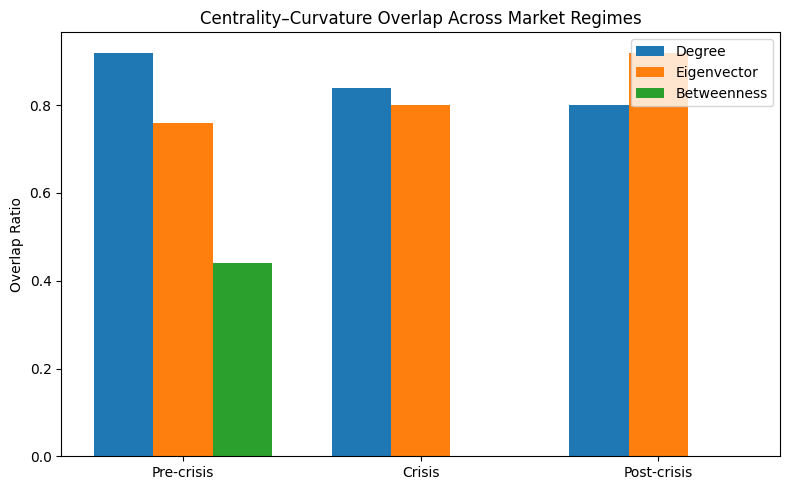

In [ ]:
plt.figure(figsize=(8,5))

x = np.arange(len(comparison_df2["Regime"]))
width = 0.25

plt.bar(
    x - width,
    comparison_df2["Degree"],
    width,
    label="Degree"
)

plt.bar(
    x,
    comparison_df2["Eigenvector"],
    width,
    label="Eigenvector"
)

plt.bar(
    x + width,
    comparison_df2["Betweenness"],
    width,
    label="Betweenness"
)

plt.xticks(x, comparison_df2["Regime"])

plt.ylabel("Overlap Ratio")
plt.title("Centrality–Curvature Overlap Across Market Regimes")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RANK CORRELATION ANALYSIS
# ============================================================
# This extends the overlap analysis with Spearman rank correlations
# to address the reviewer's comment about statistical testing.
# ============================================================
from scipy.stats import spearmanr, norm, fisher_exact
import numpy as np

def centrality_rank_correlation(G):
    """
    Compute Spearman rank correlations between curvature-fragility
    rankings and centrality rankings.
    """
    degree_cent = nx.degree_centrality(G)
    eigen_cent = safe_eigenvector_centrality(G, weight="weight")
    between_cent = nx.betweenness_centrality(G, weight="weight")

    node_frc = {
        node: G.nodes[node].get("formanCurvature", 0)
        for node in G.nodes()
    }

    # Get the nodes and their rankings
    nodes = list(G.nodes())
    frc_rank = [node_frc[node] for node in nodes]
    degree_rank = [degree_cent[node] for node in nodes]
    eigen_rank = [eigen_cent[node] for node in nodes]
    between_rank = [between_cent[node] for node in nodes]

    # Spearman correlation between curvature rankings and centrality rankings
    r_degree, p_degree = spearmanr(frc_rank, degree_rank)
    r_eigen, p_eigen = spearmanr(frc_rank, eigen_rank)
    r_between, p_between = spearmanr(frc_rank, between_rank)

    return {
        "Degree ρ": r_degree,
        "Degree p-value": p_degree,
        "Eigenvector ρ": r_eigen,
        "Eigenvector p-value": p_eigen,
        "Betweenness ρ": r_between,
        "Betweenness p-value": p_between
    }

# Compute rank correlations for each regime
print("\n" + "="*60)
print("SPEARMAN RANK CORRELATIONS")
print("="*60)

rank_corr_results = {}

for regime, G in curv_graphs.items():
    print(f"\n{regime}:")
    results = centrality_rank_correlation(G)
    rank_corr_results[regime] = results

    print(f"  Degree: ρ = {results['Degree ρ']:.3f}, p = {results['Degree p-value']:.3e}")
    print(f"  Eigenvector: ρ = {results['Eigenvector ρ']:.3f}, p = {results['Eigenvector p-value']:.3e}")
    print(f"  Betweenness: ρ = {results['Betweenness ρ']:.3f}, p = {results['Betweenness p-value']:.3e}")

# Compare correlations using Fisher's z-transformation
print("\n" + "="*60)
print("COMPARING CORRELATIONS (Fisher's z-test)")
print("="*60)


def compare_correlations(r1, r2, n):
    """Compare two correlation coefficients using Fisher's z-transformation."""
    # Handle edge cases where r is exactly 1 or -1
    r1 = np.clip(r1, -0.9999, 0.9999)
    r2 = np.clip(r2, -0.9999, 0.9999)

    z1 = 0.5 * np.log((1 + r1) / (1 - r1))
    z2 = 0.5 * np.log((1 + r2) / (1 - r2))
    se = np.sqrt(1/(n - 3) + 1/(n - 3))
    z_diff = (z1 - z2) / se
    p_value = 2 * (1 - norm.cdf(np.abs(z_diff)))
    return z_diff, p_value

n = len(curv_graphs['Crisis'].nodes())

for regime in ['Crisis', 'Post-crisis']:
    r_eigen = rank_corr_results[regime]['Eigenvector ρ']
    r_between = rank_corr_results[regime]['Betweenness ρ']
    z_diff, p_val = compare_correlations(r_eigen, r_between, n)
    print(f"\n{regime}:")
    print(f"  Eigenvector vs Betweenness: z = {z_diff:.3f}, p = {p_val:.3e}")


SPEARMAN RANK CORRELATIONS

Pre-crisis:
  Degree: ρ = -0.988, p = 0.000e+00
  Eigenvector: ρ = -0.994, p = 0.000e+00
  Betweenness: ρ = -0.734, p = 6.391e-69

Crisis:
  Degree: ρ = -0.996, p = 0.000e+00
  Eigenvector: ρ = -0.998, p = 0.000e+00
  Betweenness: ρ = -0.140, p = 4.955e-03

Post-crisis:
  Degree: ρ = -0.976, p = 1.162e-267
  Eigenvector: ρ = -0.995, p = 0.000e+00
  Betweenness: ρ = -0.546, p = 1.501e-32

COMPARING CORRELATIONS (Fisher's z-test)

Crisis:
  Eigenvector vs Betweenness: z = -46.023, p = 0.000e+00

Post-crisis:
  Eigenvector vs Betweenness: z = -33.524, p = 0.000e+00


In [ ]:
# ============================================================
# Fast Temporal Curvature Evolution
# Avoids repeated NetworkX graph construction
# ============================================================

window_size = 24
step_size = 1
threshold = 0.4

rolling_curvature = []
rolling_density = []
rolling_edges = []
dates = []

stocks = returns.columns
n = len(stocks)
possible_edges = n * (n - 1) / 2

for start in range(0, len(returns) - window_size + 1, step_size):

    subset = returns.iloc[start:start + window_size]

    corr = subset.corr().values

    # Keep only upper-triangular edges above threshold
    mask = np.triu(corr > threshold, k=1)

    edge_i, edge_j = np.where(mask)
    edge_weights = corr[edge_i, edge_j]

    m = len(edge_weights)

    if m == 0:
        continue

    # Weighted adjacency matrix
    A = np.zeros_like(corr)
    A[edge_i, edge_j] = edge_weights
    A[edge_j, edge_i] = edge_weights

    # Precompute inverse square-root terms
    frc_values = []

    for i, j, w_e in zip(edge_i, edge_j, edge_weights):

        neighbors_i = np.where(A[i] > 0)[0]
        neighbors_j = np.where(A[j] > 0)[0]

        neighbors_i = neighbors_i[neighbors_i != j]
        neighbors_j = neighbors_j[neighbors_j != i]

        sum_i = np.sum(1 / np.sqrt(w_e * A[i, neighbors_i])) if len(neighbors_i) > 0 else 0
        sum_j = np.sum(1 / np.sqrt(w_e * A[j, neighbors_j])) if len(neighbors_j) > 0 else 0

        frc = w_e * ((1 / w_e) + (1 / w_e) - sum_i - sum_j)

        frc_values.append(frc)

    rolling_curvature.append(np.mean(frc_values))
    rolling_density.append(m / possible_edges)
    rolling_edges.append(m)
    dates.append(subset.index[-1])

In [ ]:
print("Number of rolling windows:", len(rolling_curvature))
print("First date:", dates[0])
print("Last date:", dates[-1])

Number of rolling windows: 95
First date: 2008-02-01 00:00:00
Last date: 2015-12-01 00:00:00


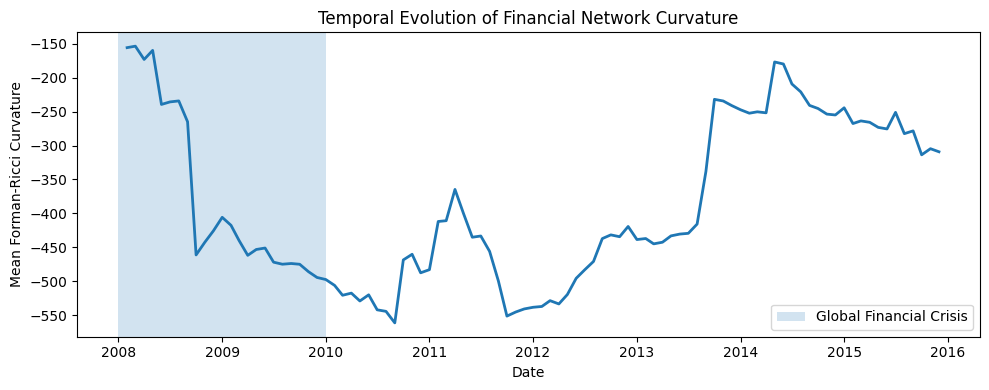

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(dates, rolling_curvature, linewidth=2)

plt.axvspan(
    pd.Timestamp("2008-01-01"),
    pd.Timestamp("2009-12-31"),
    alpha=0.2,
    label="Global Financial Crisis"
)

plt.xlabel("Date")
plt.ylabel("Mean Forman-Ricci Curvature")
plt.title("Temporal Evolution of Financial Network Curvature")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Random shock robustness test
np.random.seed(42)

random_shock_results = []

for node in np.random.choice(list(crisis_graph.nodes()), 50, replace=False):

    base = propagate_shock(
        crisis_graph,
        shocked_node=node,
        shock_size=0.5,
        gamma=0.95,
        max_steps=25,
        curvature_adjusted=False
    )

    curv = propagate_shock(
        crisis_graph,
        shocked_node=node,
        shock_size=0.5,
        gamma=0.95,
        max_steps=25,
        curvature_adjusted=True,
        alpha=0.5
    )

    random_shock_results.append({
        "Shock Node": node,
        "Baseline Final Distress": base["total_distress"][-1],
        "Curvature Final Distress": curv["total_distress"][-1],
        "Difference": curv["total_distress"][-1] - base["total_distress"][-1]
    })

random_shock_df = pd.DataFrame(random_shock_results)
random_shock_df.describe()

,Baseline Final Distress,Curvature Final Distress,Difference
count,50.000000,50.000000,50.000000
mean,7.147960,7.013053,-0.134907
std,2.922323,4.204362,1.474282
min,1.474974,0.926816,-1.652827
25%,4.772729,3.220024,-1.218506
50%,7.541385,6.768424,-0.670182
75%,9.196451,9.640718,0.511079
max,12.038691,15.809807,3.771116


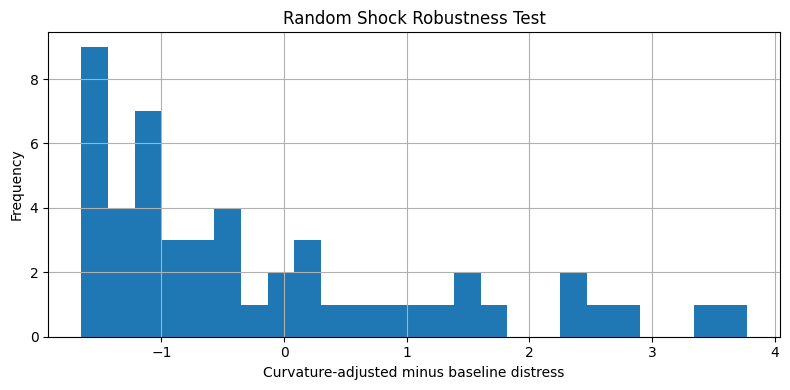

In [ ]:
plt.figure(figsize=(8, 4))
random_shock_df["Difference"].hist(bins=25)

plt.xlabel("Curvature-adjusted minus baseline distress")
plt.ylabel("Frequency")
plt.title("Random Shock Robustness Test")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

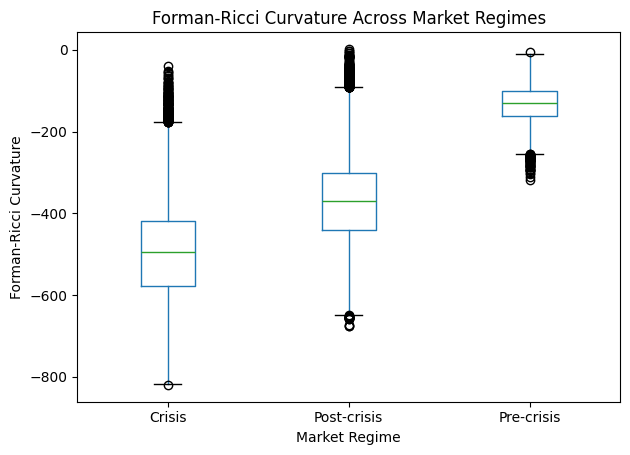

In [ ]:
# ============================================================
# Regime curvature distribution plot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

curvature_rows = []

for regime, G in curv_graphs.items():
    for _, _, data in G.edges(data=True):
        curvature_rows.append({
            "Regime": regime,
            "Forman-Ricci Curvature": data["formanCurvature"]
        })

curvature_df = pd.DataFrame(curvature_rows)

plt.figure(figsize=(8, 5))

curvature_df.boxplot(
    column="Forman-Ricci Curvature",
    by="Regime",
    grid=False
)

plt.title("Forman-Ricci Curvature Across Market Regimes")
plt.suptitle("")
plt.xlabel("Market Regime")
plt.ylabel("Forman-Ricci Curvature")
plt.tight_layout()

plt.savefig(
    "regime_curvature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

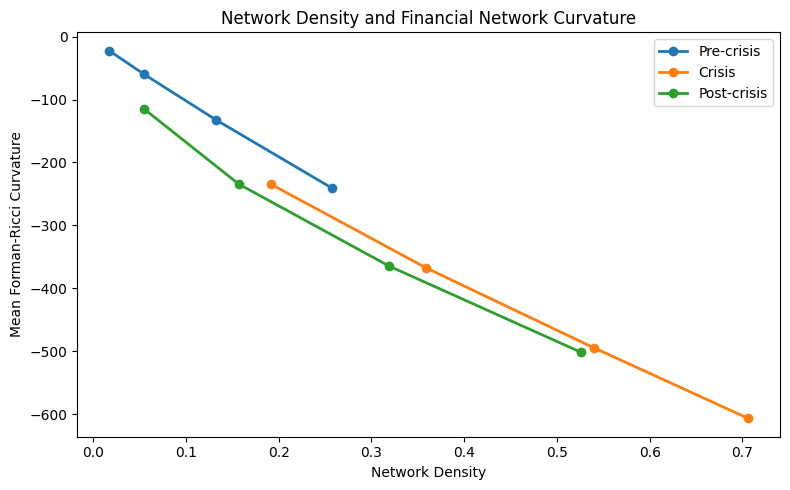

In [ ]:
# ============================================================
# Density vs Curvature plot
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for regime in threshold_df["Regime"].unique():
    subset = threshold_df[threshold_df["Regime"] == regime]

    plt.plot(
        subset["Density"],
        subset["Mean FRC"],
        marker="o",
        linewidth=2,
        label=regime
    )

plt.xlabel("Network Density")
plt.ylabel("Mean Forman-Ricci Curvature")
plt.title("Network Density and Financial Network Curvature")
plt.legend()
plt.tight_layout()

plt.savefig(
    "density_vs_curvature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

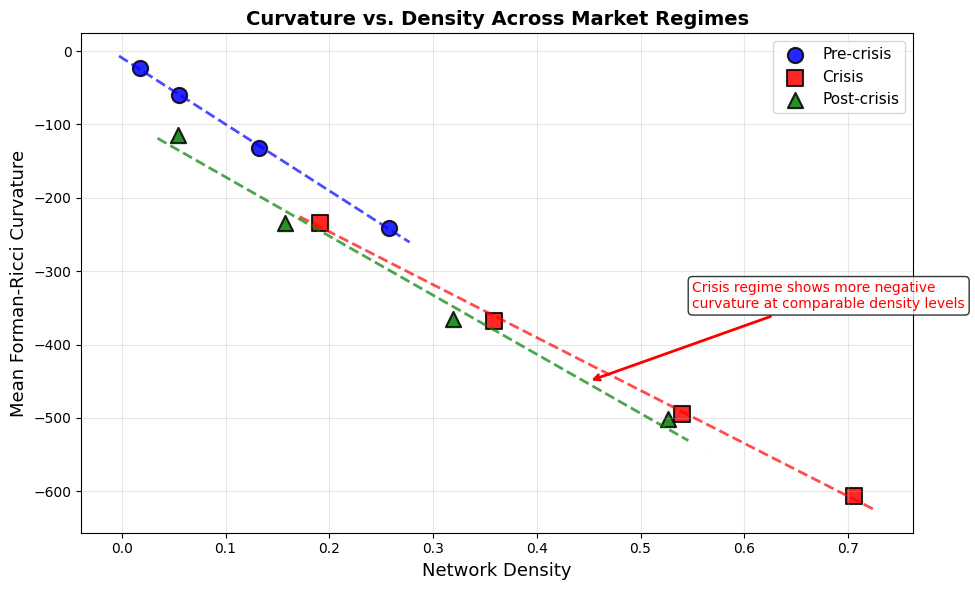


REGRESSION STATISTICS: CURVATURE VS DENSITY

Pre-crisis:
  Slope: -906.20
  Intercept: -9.07
  R-squared: 0.999
  P-value: 3.504e-04

Crisis:
  Slope: -721.08
  Intercept: -101.94
  R-squared: 0.999
  P-value: 6.919e-04

Post-crisis:
  Slope: -805.43
  Intercept: -91.03
  R-squared: 0.986
  P-value: 6.925e-03


In [ ]:
# ============================================================
# CURVATURE VS DENSITY ANALYSIS
# ============================================================
# This analysis addresses the reviewer's concern that results
# might be driven solely by higher network density during crises.
# ============================================================

from scipy import stats

plt.figure(figsize=(10, 6))

# Define colors and markers for each regime
regime_styles = {
    'Pre-crisis': {'color': 'blue', 'marker': 'o'},
    'Crisis': {'color': 'red', 'marker': 's'},
    'Post-crisis': {'color': 'green', 'marker': '^'}
}

# Plot each regime
for regime in threshold_df["Regime"].unique():
    subset = threshold_df[threshold_df["Regime"] == regime]
    style = regime_styles[regime]

    plt.scatter(
        subset["Density"],
        subset["Mean FRC"],
        label=regime,
        color=style['color'],
        marker=style['marker'],
        s=120,
        edgecolors='black',
        linewidth=1.5,
        alpha=0.85
    )

    # Add a regression line for each regime
    if len(subset) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            subset["Density"], subset["Mean FRC"]
        )
        x_line = np.linspace(subset["Density"].min() - 0.02,
                            subset["Density"].max() + 0.02, 100)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line,
                color=style['color'],
                linestyle='--',
                alpha=0.7,
                linewidth=2,
                label=f'{regime} (slope={slope:.0f})' if len(subset) == len(threshold_df["Regime"].unique()) else None)

plt.xlabel("Network Density", fontsize=13)
plt.ylabel("Mean Forman-Ricci Curvature", fontsize=13)
plt.title("Curvature vs. Density Across Market Regimes", fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

# Add annotation explaining the key finding
plt.annotate(
    "Crisis regime shows more negative\ncurvature at comparable density levels",
    xy=(0.45, -450),
    xytext=(0.55, -350),
    arrowprops=dict(arrowstyle='->', color='red', lw=2),
    fontsize=10,
    color='red',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.savefig('curvature_vs_density.png', dpi=300, bbox_inches='tight')
plt.show()

# Print regression statistics
print("\n" + "="*60)
print("REGRESSION STATISTICS: CURVATURE VS DENSITY")
print("="*60)
for regime in threshold_df["Regime"].unique():
    subset = threshold_df[threshold_df["Regime"] == regime]
    if len(subset) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            subset["Density"], subset["Mean FRC"]
        )
        print(f"\n{regime}:")
        print(f"  Slope: {slope:.2f}")
        print(f"  Intercept: {intercept:.2f}")
        print(f"  R-squared: {r_value**2:.3f}")
        print(f"  P-value: {p_value:.3e}")

In [ ]:
# ============================================================
# STATISTICAL SIGNIFICANCE TESTING
# ============================================================
# This analysis addresses the reviewer's concern about
# statistical significance of curvature differences.
# ============================================================

import seaborn as sns

# Get curvature values for each regime
pre_curv = [d['formanCurvature'] for _, _, d in curv_graphs['Pre-crisis'].edges(data=True)]
crisis_curv = [d['formanCurvature'] for _, _, d in curv_graphs['Crisis'].edges(data=True)]
post_curv = [d['formanCurvature'] for _, _, d in curv_graphs['Post-crisis'].edges(data=True)]

# ============================================================
# 1. Mann-Whitney U Tests
# ============================================================
print("\n" + "="*60)
print("MANN-WHITNEY U TESTS")
print("="*60)

# Pre-crisis vs Crisis
u_stat, p_pre_crisis = stats.mannwhitneyu(pre_curv, crisis_curv, alternative='less')
print(f"\nPre-crisis vs Crisis:")
print(f"  U-statistic: {u_stat:.2e}")
print(f"  p-value: {p_pre_crisis:.2e}")

# Pre-crisis vs Post-crisis
u_stat, p_pre_post = stats.mannwhitneyu(pre_curv, post_curv, alternative='less')
print(f"\nPre-crisis vs Post-crisis:")
print(f"  U-statistic: {u_stat:.2e}")
print(f"  p-value: {p_pre_post:.2e}")

# Crisis vs Post-crisis
u_stat, p_crisis_post = stats.mannwhitneyu(crisis_curv, post_curv, alternative='less')
print(f"\nCrisis vs Post-crisis:")
print(f"  U-statistic: {u_stat:.2e}")
print(f"  p-value: {p_crisis_post:.2e}")


MANN-WHITNEY U TESTS

Pre-crisis vs Crisis:
  U-statistic: 4.59e+08
  p-value: 1.00e+00

Pre-crisis vs Post-crisis:
  U-statistic: 2.61e+08
  p-value: 1.00e+00

Crisis vs Post-crisis:
  U-statistic: 2.28e+08
  p-value: 0.00e+00


In [ ]:
# ============================================================
# 2. Bootstrap Confidence Intervals
# ============================================================
print("\n" + "="*60)
print("BOOTSTRAP CONFIDENCE INTERVALS (95%)")
print("="*60)

def bootstrap_ci(data, n_iterations=10000, ci=95):
    """Compute bootstrap confidence intervals."""
    n = len(data)
    means = []
    for _ in range(n_iterations):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(bootstrap_sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return lower, upper, np.std(means)

# Compute CIs for each regime
regimes = {
    'Pre-crisis': pre_curv,
    'Crisis': crisis_curv,
    'Post-crisis': post_curv
}

ci_results = {}
for name, data in regimes.items():
    lower, upper, std_err = bootstrap_ci(data)
    ci_results[name] = {
        'mean': np.mean(data),
        'std': np.std(data),
        'ci_lower': lower,
        'ci_upper': upper,
        'std_err': std_err
    }
    print(f"\n{name}:")
    print(f"  Mean: {np.mean(data):.2f}")
    print(f"  Std: {np.std(data):.2f}")
    print(f"  95% CI: [{lower:.2f}, {upper:.2f}]")
    print(f"  Standard Error: {std_err:.2f}")


BOOTSTRAP CONFIDENCE INTERVALS (95%)

Pre-crisis:
  Mean: -132.42
  Std: 46.06
  95% CI: [-133.29, -131.54]
  Standard Error: 0.45

Crisis:
  Mean: -494.49
  Std: 115.08
  95% CI: [-495.55, -493.42]
  Standard Error: 0.55

Post-crisis:
  Mean: -364.56
  Std: 108.40
  95% CI: [-365.92, -363.26]
  Standard Error: 0.68


In [ ]:
 # ============================================================
# 3. Permutation Test (Null Model)
# ============================================================
print("\n" + "="*60)
print("PERMUTATION TEST (NULL MODEL)")
print("="*60)

def permutation_test(data1, data2, n_permutations=1000):
    """Perform permutation test for difference in means."""
    combined = np.concatenate([data1, data2])
    n1 = len(data1)
    observed_diff = np.mean(data1) - np.mean(data2)

    perm_diffs = []
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_diff = np.mean(combined[:n1]) - np.mean(combined[n1:])
        perm_diffs.append(perm_diff)

    # Two-sided p-value
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, perm_diffs, p_value

# Pre-crisis vs Crisis
obs_diff, perm_diffs, p_val = permutation_test(pre_curv, crisis_curv)
print(f"\nPre-crisis vs Crisis:")
print(f"  Observed difference: {obs_diff:.2f}")
print(f"  Permutation p-value: {p_val:.4f}")

# Pre-crisis vs Post-crisis
obs_diff, perm_diffs, p_val = permutation_test(pre_curv, post_curv)
print(f"\nPre-crisis vs Post-crisis:")
print(f"  Observed difference: {obs_diff:.2f}")
print(f"  Permutation p-value: {p_val:.4f}")


PERMUTATION TEST (NULL MODEL)

Pre-crisis vs Crisis:
  Observed difference: 362.07
  Permutation p-value: 0.0000

Pre-crisis vs Post-crisis:
  Observed difference: 232.15
  Permutation p-value: 0.0000


In [ ]:
# ============================================================
# 4. Null Model: Random Edge Weight Permutation
# ============================================================

from joblib import Parallel, delayed
import numpy as np

print("\n" + "="*60)
print("NULL MODEL: RANDOM EDGE WEIGHT PERMUTATION")
print("="*60)


# ------------------------------------------------------------
# Single permutation
# ------------------------------------------------------------
def one_permutation(edges, weights, G):

    shuffled_weights = np.random.permutation(weights)

    G_null = G.copy()

    for i, (u, v, _) in enumerate(edges):
        G_null[u][v]["weight"] = shuffled_weights[i]

    G_null = FormanRicci(G_null).compute_ricci_curvature()

    frc_vals = [
        d["formanCurvature"]
        for _, _, d in G_null.edges(data=True)
    ]

    return np.mean(frc_vals)


# ------------------------------------------------------------
# Null distribution
# ------------------------------------------------------------
def null_model_curvature(
    G,
    n_permutations=100,
    n_jobs=-1
):

    edges = list(G.edges(data=True))

    weights = np.array([
        data["weight"]
        for _, _, data in edges
    ])

    null_means = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        verbose=0
    )(
        delayed(one_permutation)(
            edges,
            weights,
            G
        )
        for _ in range(n_permutations)
    )

    return np.array(null_means)


# ------------------------------------------------------------
# Compute null distributions
# ------------------------------------------------------------
print("Computing null distributions (100 permutations each)...")

null_results = {}

for name, G in curv_graphs.items():

    print(f"\n{name}")

    observed_mean = np.mean([
        d["formanCurvature"]
        for _, _, d in G.edges(data=True)
    ])

    null_means = null_model_curvature(
        G,
        n_permutations=100,
        n_jobs=-1
    )

    null_mean = np.mean(null_means)
    null_std = np.std(null_means)

    z_score = (
        observed_mean - null_mean
    ) / null_std

    p_value = np.mean(
        np.abs(null_means - null_mean)
        >=
        np.abs(observed_mean - null_mean)
    )

    null_results[name] = {
        "observed_mean": observed_mean,
        "null_mean": null_mean,
        "null_std": null_std,
        "z_score": z_score,
        "p_value": p_value,
        "values": null_means
    }

    print(f"Observed Mean FRC : {observed_mean:.2f}")
    print(f"Null Mean FRC     : {null_mean:.2f}")
    print(f"Null Std          : {null_std:.2f}")
    print(f"Z-score           : {z_score:.2f}")
    print(f"Permutation p-val : {p_value:.4f}")


NULL MODEL: RANDOM EDGE WEIGHT PERMUTATION
Computing null distributions (100 permutations each)...

Pre-crisis
Observed Mean FRC : -132.42
Null Mean FRC     : -132.42
Null Std          : 0.00
Z-score           : 1.91
Permutation p-val : 0.0400

Crisis
Observed Mean FRC : -494.49
Null Mean FRC     : -494.91
Null Std          : 0.00
Z-score           : 95.47
Permutation p-val : 0.0000

Post-crisis
Observed Mean FRC : -364.56
Null Mean FRC     : -364.91
Null Std          : 0.01
Z-score           : 61.68
Permutation p-val : 0.0000


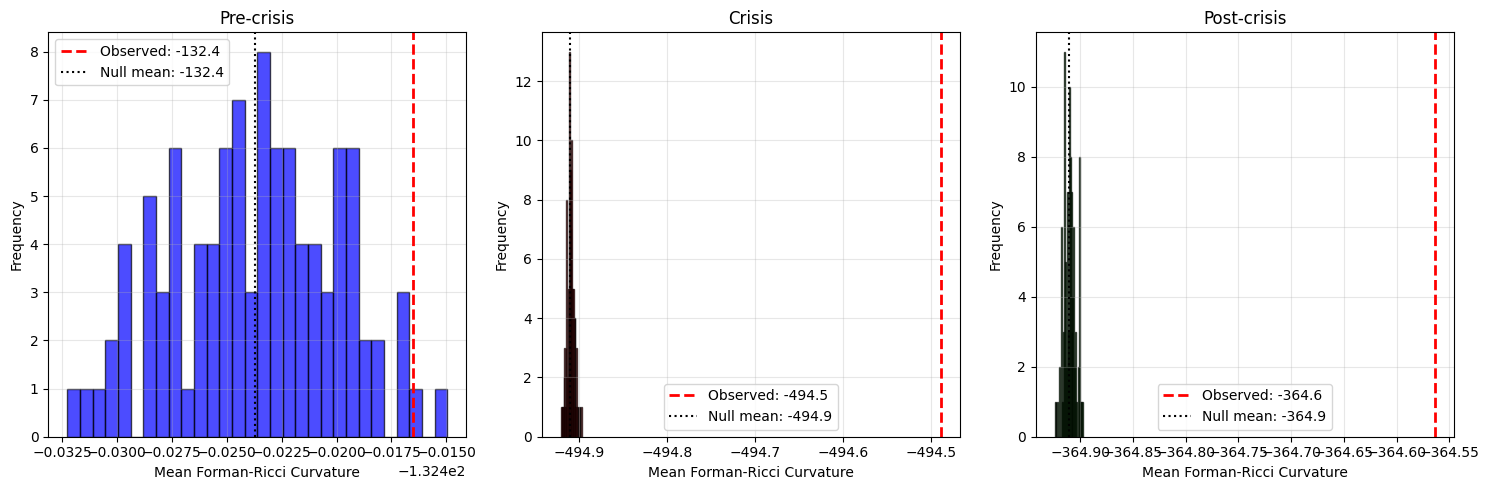

In [ ]:
# ============================================================
# 5. Plot Null Model Comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'Pre-crisis': 'blue', 'Crisis': 'red', 'Post-crisis': 'green'}

for idx, (name, G) in enumerate(curv_graphs.items()):
    ax = axes[idx]
    null_means = null_results[name]['values']
    observed_mean = np.mean([d['formanCurvature'] for _, _, d in G.edges(data=True)])

    # Histogram of null distribution
    ax.hist(null_means, bins=30, alpha=0.7, color=colors[name], edgecolor='black')

    # Vertical line for observed mean
    ax.axvline(observed_mean, color='red', linestyle='--', linewidth=2,
               label=f'Observed: {observed_mean:.1f}')

    # Vertical line for null mean
    null_mean = np.mean(null_means)
    ax.axvline(null_mean, color='black', linestyle=':', linewidth=1.5,
               label=f'Null mean: {null_mean:.1f}')

    ax.set_xlabel('Mean Forman-Ricci Curvature')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('null_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# ============================================================
# 6. Summary Table for Paper
# ============================================================
summary_data = []
for name in ['Pre-crisis', 'Crisis', 'Post-crisis']:
    data = regimes[name]
    ci = ci_results[name]
    summary_data.append({
        'Regime': name,
        'Mean FRC': f"${np.mean(data):.2f}$",
        'Std': f"${np.std(data):.2f}$",
        '95% CI Lower': f"${ci['ci_lower']:.2f}$",
        '95% CI Upper': f"${ci['ci_upper']:.2f}$",
        'Negative Ratio': f"{np.mean(np.array(data) < 0):.3f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("SUMMARY TABLE FOR PAPER")
print("="*60)
print(summary_df.to_string(index=False))


SUMMARY TABLE FOR PAPER
     Regime  Mean FRC      Std 95% CI Lower 95% CI Upper Negative Ratio
 Pre-crisis $-132.42$  $46.06$    $-133.29$    $-131.54$          1.000
     Crisis $-494.49$ $115.08$    $-495.55$    $-493.42$          1.000
Post-crisis $-364.56$ $108.40$    $-365.92$    $-363.26$          1.000
